# Anemoi-datasets

This notebook is a hands-on introduction to anemoi-datasets. The full documentation of the package can be found here: https://anemoi.readthedocs.io/projects/datasets/en/latest/

## Overview

The anemoi-datasets package provides a structured approach to **preparing datasets for data-driven weather forecasting models**. 

By optimising data access patterns, anemoi-datasets minimises I/O operations, improving efficiency when training machine learning models.

It offers a simple high-level interface based on a **YAML recipe file**, which defines how datasets are processed and structured.

Using anemoi-datasets, you can:

- Load and transform datasets from sources such as reanalyses or forecasts.

- Interpolate data to a desired spatial resolution and temporal frequency to match model requirements.

- Select and preprocess relevant meteorological variables for use in machine learning workflows.

- Structure datasets for efficient access in training and inference, reducing unnecessary data operations.

## Installation

```bash
pip install anemoi-datasets
```

If you are using the standard virtual environment prepared for the class, the package should have been pre-installed for you.

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cartopy.feature as cfeature
from matplotlib.axes import Axes

%matplotlib inline
%config InlineBackend.figure_format='retina'

In [13]:
import numpy as np

## Open and inspect a dataset

In [ ]:
from anemoi.datasets import open_dataset

ds = open_dataset(
    "ma-lm15-pl6-20240821-20240830-6h.zarr",  # make sure to use the full path to the dataset!
)

ds

In [4]:
# what are the dates in the dataset?
ds.dates

array(['2024-08-21T00:00:00', '2024-08-21T06:00:00',
       '2024-08-21T12:00:00', '2024-08-21T18:00:00',
       '2024-08-22T00:00:00', '2024-08-22T06:00:00',
       '2024-08-22T12:00:00', '2024-08-22T18:00:00',
       '2024-08-23T00:00:00', '2024-08-23T06:00:00',
       '2024-08-23T12:00:00', '2024-08-23T18:00:00',
       '2024-08-24T00:00:00', '2024-08-24T06:00:00',
       '2024-08-24T12:00:00', '2024-08-24T18:00:00',
       '2024-08-25T00:00:00', '2024-08-25T06:00:00',
       '2024-08-25T12:00:00', '2024-08-25T18:00:00',
       '2024-08-26T00:00:00', '2024-08-26T06:00:00',
       '2024-08-26T12:00:00', '2024-08-26T18:00:00',
       '2024-08-27T00:00:00', '2024-08-27T06:00:00',
       '2024-08-27T12:00:00', '2024-08-27T18:00:00',
       '2024-08-28T00:00:00', '2024-08-28T06:00:00',
       '2024-08-28T12:00:00', '2024-08-28T18:00:00',
       '2024-08-29T00:00:00', '2024-08-29T06:00:00',
       '2024-08-29T12:00:00', '2024-08-29T18:00:00',
       '2024-08-30T00:00:00', '2024-08-30T06:0

In [5]:
# how about the variables?
ds.variables

['10u',
 '10v',
 '2d',
 '2t',
 'cos_julian_day',
 'cos_latitude',
 'cos_local_time',
 'cos_longitude',
 'insolation',
 'lsm',
 'msl',
 'orog',
 'q_200',
 'q_300',
 'q_400',
 'q_500',
 'q_700',
 'q_850',
 'sin_julian_day',
 'sin_latitude',
 'sin_local_time',
 'sin_longitude',
 'sp',
 't_200',
 't_300',
 't_400',
 't_500',
 't_700',
 't_850',
 'tcc',
 'tcwv',
 'tp',
 'u_200',
 'u_300',
 'u_400',
 'u_500',
 'u_700',
 'u_850',
 'v_200',
 'v_300',
 'v_400',
 'v_500',
 'v_700',
 'v_850',
 'w_200',
 'w_300',
 'w_400',
 'w_500',
 'w_700',
 'w_850',
 'z_200',
 'z_300',
 'z_400',
 'z_500',
 'z_700',
 'z_850']

## Metadata

Anemoi datasets contain useful metadata. For this gridded dataset, we can query things like:

In [7]:
# "supporting arrays": latitude/longitude coordinates for the grid points

ds.supporting_arrays()

{'latitudes': array([16.808735  , 16.84671201, 16.88451616, ..., 49.2298914 ,
        49.19915483, 49.1680635 ], shape=(60333,)),
 'longitudes': array([115.144447  , 115.26845842, 115.39259253, ..., 157.68346032,
        157.89177358, 158.09984082], shape=(60333,))}

### Statistics

An anemoi-datasets includes the statistics of the variables inside the dataset, stored as a Python dictionary. You can access them using through the `statistics` property:

In [18]:
ds.statistics

{'mean': array([-5.95264929e-01,  1.51447098e+00,  2.94510332e+02,  2.98753633e+02,
        -5.94771270e-01,  8.19374153e-01,  0.00000000e+00, -6.43583709e-01,
         3.28360780e-01,  3.46192240e-01,  1.00958616e+05,  1.95543832e+02,
         3.84279985e-05,  3.51491484e-04,  1.07913240e-03,  2.38243422e-03,
         6.53287990e-03,  1.10637580e-02, -8.02914315e-01,  5.53245633e-01,
         0.00000000e+00,  7.30241560e-01,  9.88303171e+04,  2.23393987e+02,
         2.43517531e+02,  2.58199513e+02,  2.68529118e+02,  2.83064064e+02,
         2.91412048e+02,  4.32478013e-01,  4.51989184e+01,  1.32214655e+00,
         7.12142552e+00,  5.79690333e+00,  4.27659112e+00,  3.32701342e+00,
         1.98457685e+00,  8.55176390e-01, -4.12822444e+00, -2.01079859e+00,
        -9.89679894e-01, -2.18591725e-01,  8.87763285e-01,  1.68621616e+00,
        -1.35895676e-02, -1.38422797e-02, -1.29767699e-02, -1.13797182e-02,
        -6.99352124e-03, -3.08652906e-03,  1.22262190e+05,  9.51228336e+04,
    

To identify the statistics of a certain variable, you can use the `name_to_index` property of the dataset! This maps variable names to their index in the `ds.statistics` arrays:

In [19]:
ds.name_to_index

{'10u': 0,
 '10v': 1,
 '2d': 2,
 '2t': 3,
 'cos_julian_day': 4,
 'cos_latitude': 5,
 'cos_local_time': 6,
 'cos_longitude': 7,
 'insolation': 8,
 'lsm': 9,
 'msl': 10,
 'orog': 11,
 'q_200': 12,
 'q_300': 13,
 'q_400': 14,
 'q_500': 15,
 'q_700': 16,
 'q_850': 17,
 'sin_julian_day': 18,
 'sin_latitude': 19,
 'sin_local_time': 20,
 'sin_longitude': 21,
 'sp': 22,
 't_200': 23,
 't_300': 24,
 't_400': 25,
 't_500': 26,
 't_700': 27,
 't_850': 28,
 'tcc': 29,
 'tcwv': 30,
 'tp': 31,
 'u_200': 32,
 'u_300': 33,
 'u_400': 34,
 'u_500': 35,
 'u_700': 36,
 'u_850': 37,
 'v_200': 38,
 'v_300': 39,
 'v_400': 40,
 'v_500': 41,
 'v_700': 42,
 'v_850': 43,
 'w_200': 44,
 'w_300': 45,
 'w_400': 46,
 'w_500': 47,
 'w_700': 48,
 'w_850': 49,
 'z_200': 50,
 'z_300': 51,
 'z_400': 52,
 'z_500': 53,
 'z_700': 54,
 'z_850': 55}

## Question

What are the statistics useful for? What other useful information can be found in the anemoi-dataset?

https://anemoi.readthedocs.io/projects/datasets/en/latest/modules/dataset.html

## Visualizing data

In [8]:
# create a bounding box

info = ds.supporting_arrays()
latitudes, longitudes = info["latitudes"], info["longitudes"]
hires_extent = [
    int(longitudes.min()) - 2., int(longitudes.max()) + 2,
    int(latitudes.min()) - 2., int(latitudes.max()) + 2,
]
hires_extent

[99.0, 160, 14.0, 52]

In [9]:
def plot_variable(lats, lons, vardata, varname, cmap="RdYlBu_r", contour=True, extent=None):
    fig, ax = plt.subplots(
        1, 1, figsize=(12,7),
        subplot_kw={"projection": ccrs.PlateCarree()},
        # subplot_kw={"projection": ccrs.LambertConformal(central_longitude=130, central_latitude=35)},
    )

    extent = [-180., 180, -90., 90] if extent is None else extent
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="teal")
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="teal")
    gl = ax.gridlines(draw_labels=True, linewidth=0.2, color="teal", linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    if contour:
        import matplotlib.tri as mtri
 
        tri = mtri.Triangulation(lons, lats)
        bad = ~np.isfinite(vardata)
        # Mask triangles with at least one bad vertex
        tri.set_mask(bad[tri.triangles].any(axis=1))
 
        sc = ax.tricontourf(
            tri,
            vardata,
            levels=15,
            cmap=cmap,
            transform=ccrs.PlateCarree(),
        )
        # Contour lines on top
        contours = ax.tricontour(
            tri,
            vardata,
            levels=15,  # same levels
            colors="black",
            linewidths=0.7,
            transform=ccrs.PlateCarree(),
        )
        ax.clabel(contours, inline=True, fontsize=8, fmt='%1.1f')
    else:
        sc = ax.scatter(
            lons,
            lats,
            c=vardata,
            s=4,
            cmap=cmap,
            transform=ccrs.PlateCarree(),
        )
    
    sc = ax.scatter(lons, lats, c=vardata, s=5, cmap=cmap)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.1, axes_class=Axes)
    fig.colorbar(sc, ax=ax, cax=cax)
    ax.set_title(f"{varname}")
    # ax.gridlines()
    fig.show()

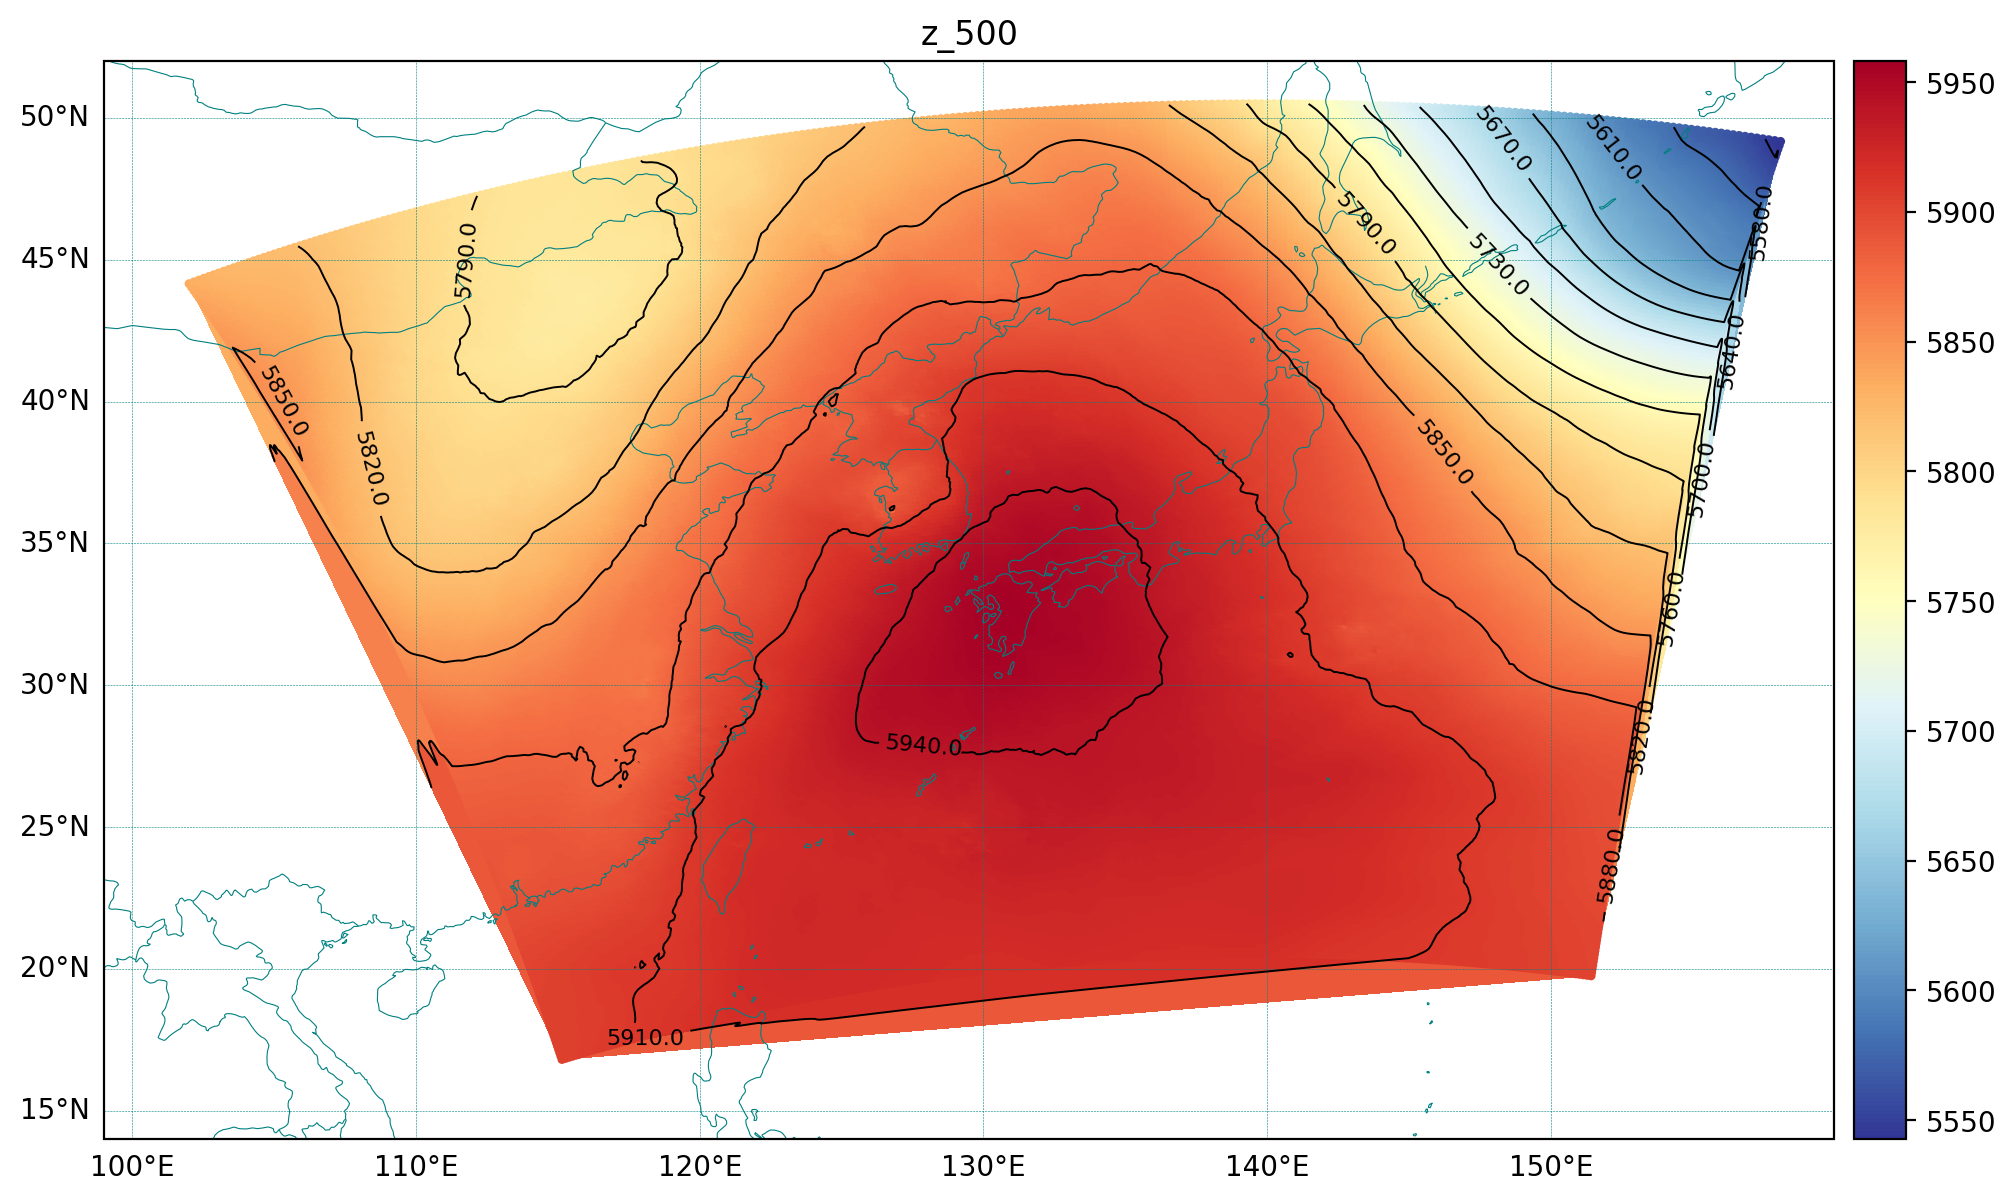

In [15]:
varname = "z_500"
vardata = ds[0][ds.name_to_index["z_500"], ...] / 9.80665 # convert to height

plot_variable(latitudes, longitudes, vardata.flatten(), varname, extent=hires_extent)

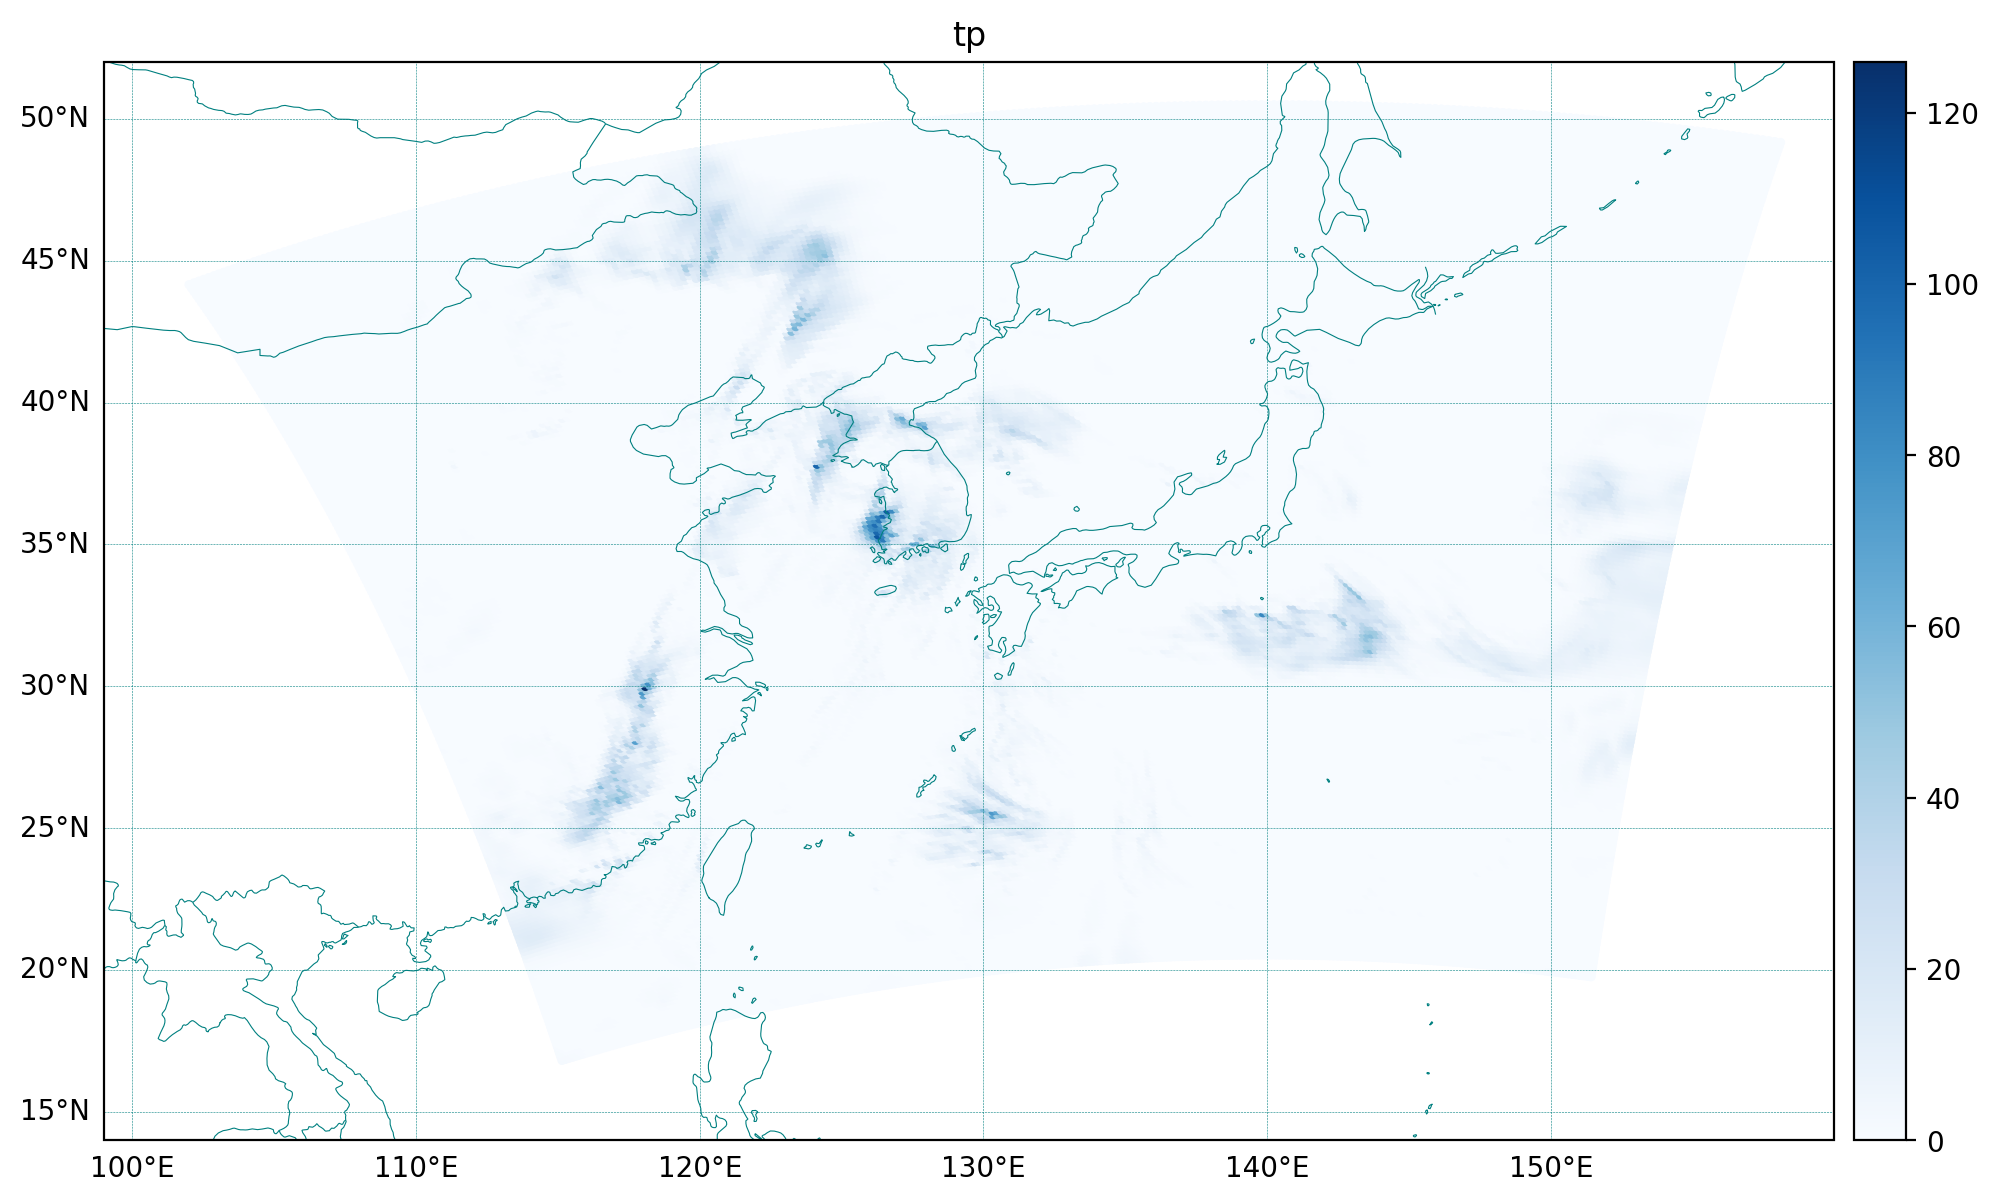

In [16]:
varname = "tp"
vardata = ds[0][ds.name_to_index["tp"], ...]
plot_variable(latitudes, longitudes, vardata.flatten(), varname, cmap="Blues", contour=False, extent=hires_extent)

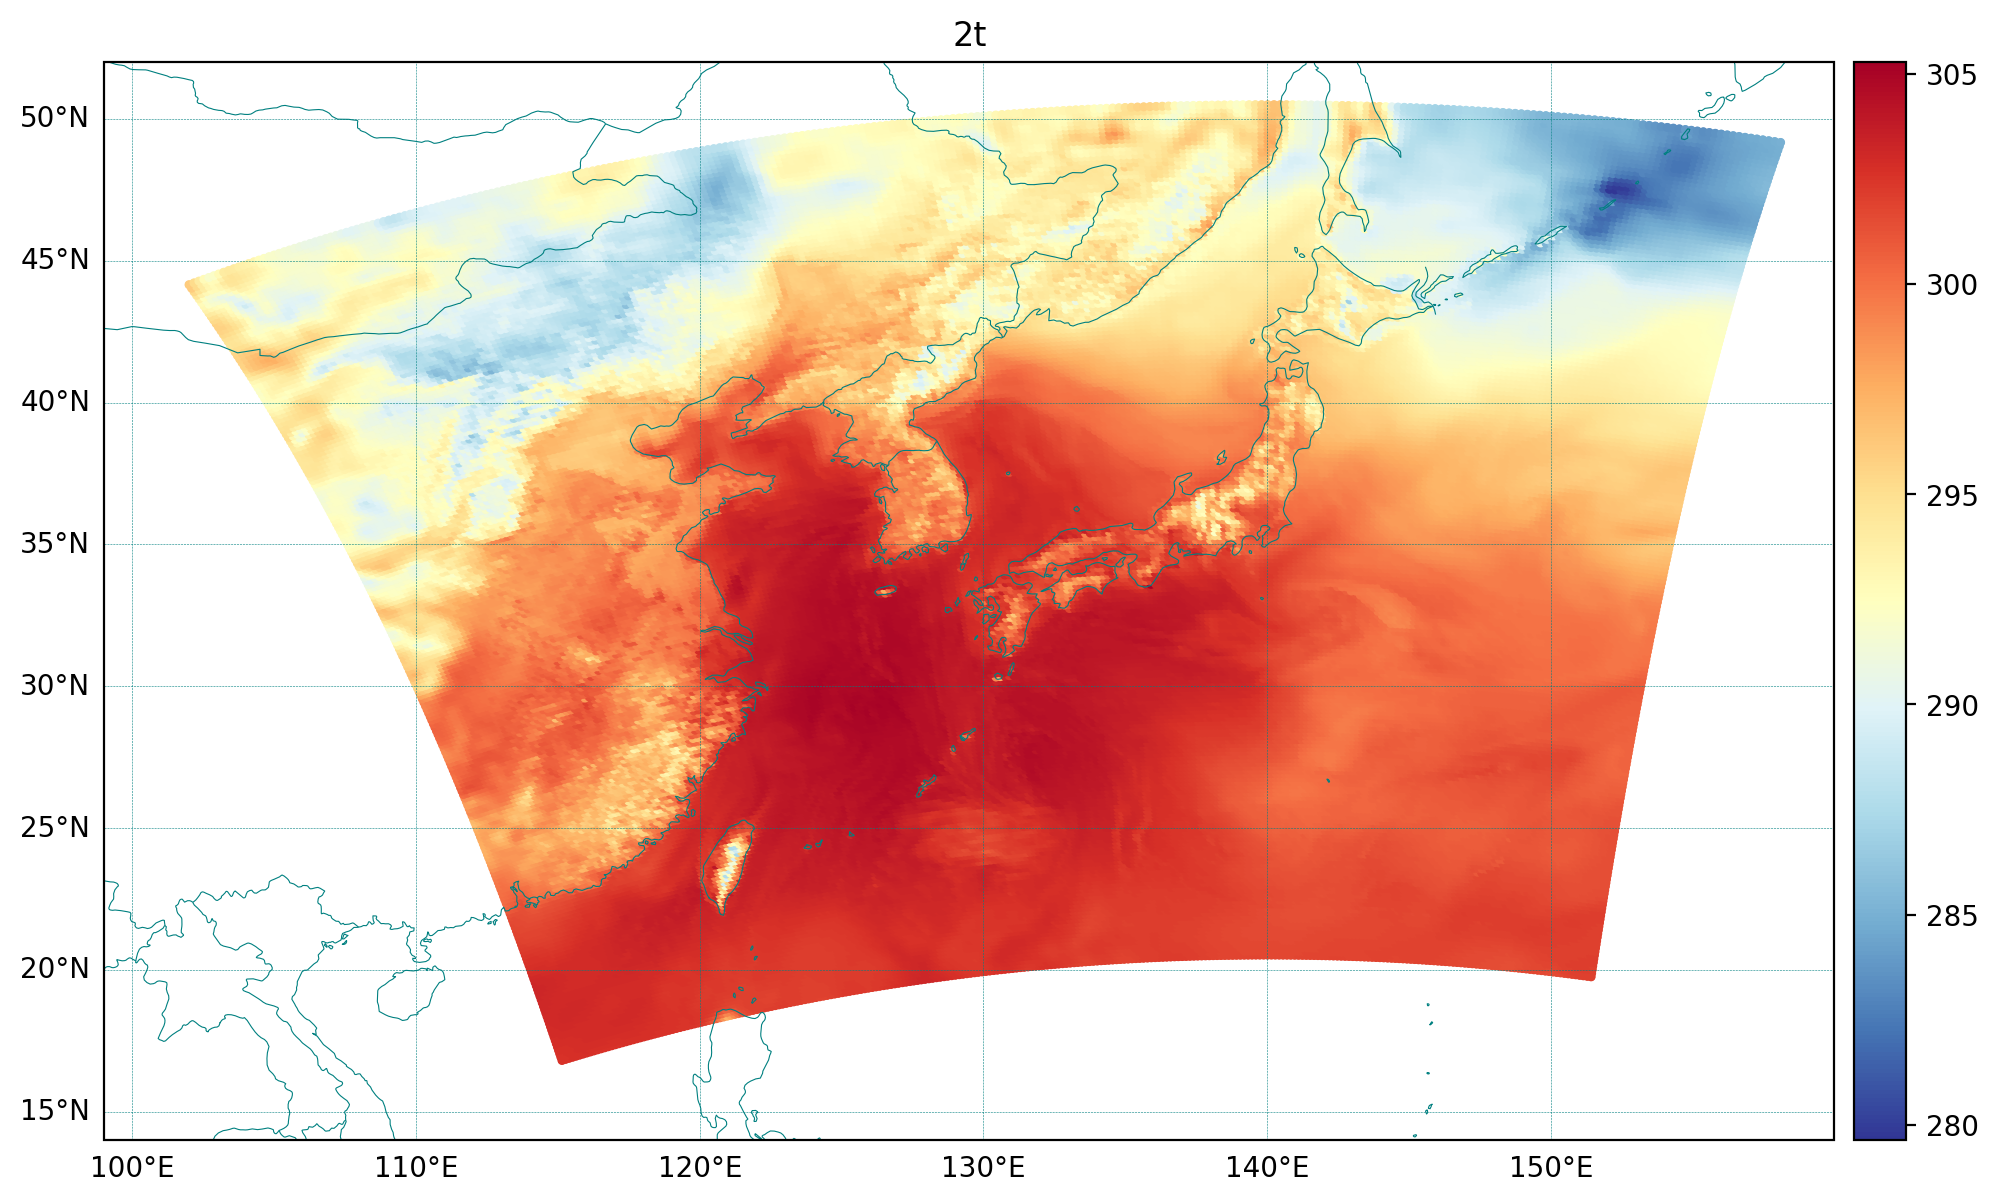

In [17]:
varname = "2t"
vardata = ds[0][ds.name_to_index["2t"], ...]

plot_variable(latitudes, longitudes, vardata.flatten(), varname, contour=False, extent=hires_extent)

## Selecting variables and/or date ranges from a dataset

`open_dataset` accepts several arguments that allow you to select (or drop) certain variables from the full dataset:

In [ ]:
ds = open_dataset(
    "ma-lm15-pl6-20240821-20240830-6h.zarr",
    start="2024-08-25 00:00:00",
    end="2024-08-31 00:00:00",
    select=["2t", "tp"],         # select 2t and tp, in this order!
)
ds

You can also rename variables! This is useful, e.g., if you are opening multiple datasets and do not want to have clashes between variable names:

In [26]:
ds_2t_renamed = open_dataset(
    "ma-lm15-pl6-20240821-20240830-6h.zarr",
    start="2024-08-25 00:00:00",
    end="2024-08-31 00:00:00",
    select=["2t"],
    rename={"2t": "2t_ma_lm15"}
)
ds_2t_renamed

rename {'2t': '2t_ma_lm15'}
select 2t
subset
start 2024-08-25 00:00:00
end 2024-08-31 00:00:00
zarr /perm/syma/AIFS/JMA/datasets/ma-lm15-pl6-20240821-20240830-6h.zarr


In [27]:
ds_2t_renamed.variables

['2t_ma_lm15']

Refer to the documentation to see what else is supported: https://anemoi.readthedocs.io/projects/datasets/en/latest/using/introduction.html

## Using the command line

https://anemoi.readthedocs.io/projects/datasets/en/latest/cli/introduction.html

The command line allows us to **create, inspect, copy and compare** Anemoi datasets.

```
(anemoi-multidataset) $ anemoi-datasets inspect ma-lm15-pl6-20240821-20240830-6h.zarr
📦 Path          : ma-lm15-pl6-20240821-20240830-6h.zarr
🔢 Format version: 0.30.0

📅 Start      : 2024-08-21 00:00
📅 End        : 2024-08-30 18:00
⏰ Frequency  : 6h
🚫 Missing    : 0
🌎 Resolution : 15p0km
🌎 Field shape: [221, 273]

📐 Shape      : 40 × 56 × 1 × 60,333 (515.5 MiB)
💽 Size       : 329.7 MiB (329.7 MiB)
📁 Files      : 79

   Index │ Variable       │         Min │         Max │        Mean │       Stdev
   ──────┼────────────────┼─────────────┼─────────────┼─────────────┼────────────
       0 │ 10u            │     -49.486 │      41.988 │   -0.595265 │      3.8804
       1 │ 10v            │    -40.8061 │     48.7168 │     1.51447 │      3.9978
       2 │ 2d             │     266.803 │     302.995 │      294.51 │     5.24342
       3 │ 2t             │     277.532 │     315.079 │     298.754 │     4.93948
       4 │ cos_julian_day │   -0.647443 │   -0.540394 │   -0.594771 │   0.0318953
       5 │ cos_latitude   │    0.636094 │    0.957275 │    0.819374 │   0.0846818
       6 │ cos_local_time │   -0.978153 │    0.978153 │           0 │    0.707107
       7 │ cos_longitude  │   -0.927835 │   -0.207886 │   -0.643584 │    0.172029
       8 │ insolation     │           0 │    0.916046 │    0.328361 │    0.343043
       9 │ lsm            │           0 │           1 │    0.346192 │    0.470675
      10 │ msl            │     93612.2 │      102502 │      100959 │      455.58
      11 │ orog           │      -17.99 │     2624.32 │     195.544 │     390.276
      12 │ q_200          │ 4.52007e-12 │ 0.000370941 │  3.8428e-05 │  2.7812e-05
      13 │ q_300          │ 6.98195e-08 │  0.00283879 │ 0.000351491 │ 0.000242912
      14 │ q_400          │ 6.39934e-07 │  0.00679561 │  0.00107913 │ 0.000820472
      15 │ q_500          │ 3.65675e-06 │   0.0102196 │  0.00238243 │  0.00167726
      16 │ q_700          │ 3.02106e-05 │   0.0172507 │  0.00653288 │  0.00273882
      17 │ q_850          │ 8.80078e-05 │   0.0216252 │   0.0110638 │  0.00318572
      18 │ sin_julian_day │   -0.841412 │   -0.762114 │   -0.802914 │   0.0236312
      19 │ sin_latitude   │    0.289178 │    0.771612 │    0.553246 │    0.123993
      20 │ sin_local_time │   -0.978153 │    0.978153 │           0 │    0.707107
      21 │ sin_longitude  │     0.37299 │    0.978153 │    0.730242 │    0.151504
      22 │ sp             │     74187.2 │      102503 │     98830.3 │     4310.84
      23 │ t_200          │     212.676 │     237.245 │     223.394 │     2.81045
      24 │ t_300          │     228.561 │     261.132 │     243.518 │     3.52093
      25 │ t_400          │     242.448 │     273.781 │       258.2 │     3.22806
      26 │ t_500          │     253.301 │       283.1 │     268.529 │     2.77442
      27 │ t_700          │     268.036 │     293.971 │     283.064 │     2.53354
      28 │ t_850          │     276.971 │     304.511 │     291.412 │     2.97677
      29 │ tcc            │           0 │           1 │    0.432478 │    0.295774
      30 │ tcwv           │     3.23052 │     93.0082 │     45.1989 │      14.893
      31 │ tp             │           0 │     412.499 │     1.32215 │     5.39203
      32 │ u_200          │    -43.6157 │      62.115 │     7.12143 │     17.3743
      33 │ u_300          │    -43.2274 │     60.8049 │      5.7969 │     12.8707
      34 │ u_400          │    -49.0205 │     55.0095 │     4.27659 │     9.67952
      35 │ u_500          │    -50.6139 │     52.9892 │     3.32701 │     7.92528
      36 │ u_700          │    -58.2437 │     56.2195 │     1.98458 │     6.11944
      37 │ u_850          │    -65.8004 │     59.1821 │    0.855176 │     5.77647
      38 │ v_200          │    -49.8566 │      47.602 │    -4.12822 │     14.3076
      39 │ v_300          │    -48.7415 │      45.864 │     -2.0108 │     11.2406
      40 │ v_400          │    -46.2534 │     49.6392 │    -0.98968 │     8.33888
      41 │ v_500          │    -50.4768 │      55.431 │   -0.218592 │     6.91531
      42 │ v_700          │    -52.7723 │     64.7832 │    0.887763 │     5.50915
      43 │ v_850          │    -52.7638 │     75.5197 │     1.68622 │      5.3704
      44 │ w_200          │    -26.0767 │     6.92383 │  -0.0135896 │    0.201083
      45 │ w_300          │    -35.4054 │     13.5914 │  -0.0138423 │    0.311436
      46 │ w_400          │    -41.7835 │     16.1188 │  -0.0129768 │    0.364642
      47 │ w_500          │    -47.7746 │     20.6093 │  -0.0113797 │    0.425778
      48 │ w_700          │    -50.8611 │     23.1906 │ -0.00699352 │    0.485986
      49 │ w_850          │    -40.2929 │     27.4678 │ -0.00308653 │    0.519973
      50 │ z_200          │      116380 │      124196 │      122262 │     1161.48
      51 │ z_300          │     90308.1 │     96577.3 │     95122.8 │     931.959
      52 │ z_400          │     70485.1 │     75537.5 │     74390.9 │     697.752
      53 │ z_500          │     52698.3 │     58574.1 │     57498.8 │     549.371
      54 │ z_700          │     24924.6 │     31840.5 │     30794.8 │     396.272
      55 │ z_850          │     8400.42 │     15754.7 │     14704.2 │     351.693
   ──────┴────────────────┴─────────────┴─────────────┴─────────────┴────────────
🔋 Dataset ready, last update on Monday 26 January 2026.
📊 Statistics ready.

```

# Exercise

Inspect the ERA5 and Himawari datasets. What variables do they store? What is their valid date range? Can you plot some data snapshots? Do they look plausible?

- `observations-himawari-ahi-zarr2-o512-202408-6h-v1.zarr`
- `ea-o96-pl6-20240821-20240830-6h.zarr`